<a href="https://colab.research.google.com/github/Pranayshukla0610/computer-vision-generative-ai-projects/blob/main/Computer_Vision_AI_Cartoon_Generatot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-python matplotlib numpy

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

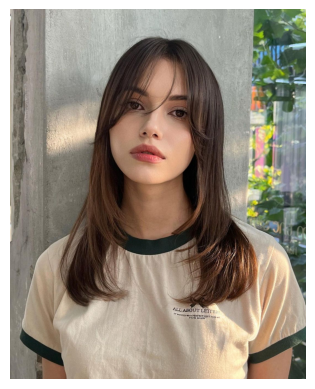

In [3]:
image = cv2.imread('/content/740full-lena-(model).jpg')

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.imshow(image)
plt.axis('off')
plt.show()

In [4]:
image = cv2.resize(
    image,
    (512,512)
)

array([[[200, 193, 183],
        [192, 185, 175],
        [185, 178, 168],
        ...,
        [191, 207, 176],
        [221, 231, 194],
        [228, 233, 191]],

       [[201, 194, 184],
        [190, 183, 173],
        [188, 182, 171],
        ...,
        [187, 207, 168],
        [195, 211, 164],
        [205, 216, 162]],

       [[204, 196, 187],
        [191, 185, 174],
        [181, 175, 163],
        ...,
        [164, 192, 145],
        [193, 216, 161],
        [205, 225, 162]],

       ...,

       [[111, 107, 101],
        [113, 109, 103],
        [119, 116, 109],
        ...,
        [ 45,  56,  46],
        [ 52,  61,  53],
        [ 44,  54,  45]],

       [[113, 109,  98],
        [112, 108,  97],
        [121, 117, 107],
        ...,
        [ 48,  59,  50],
        [ 46,  58,  47],
        [ 44,  56,  45]],

       [[115, 111, 100],
        [112, 108,  97],
        [119, 115, 104],
        ...,
        [ 66,  78,  68],
        [ 53,  66,  53],
        [ 44,  56,  44]]], dtype=uint8)
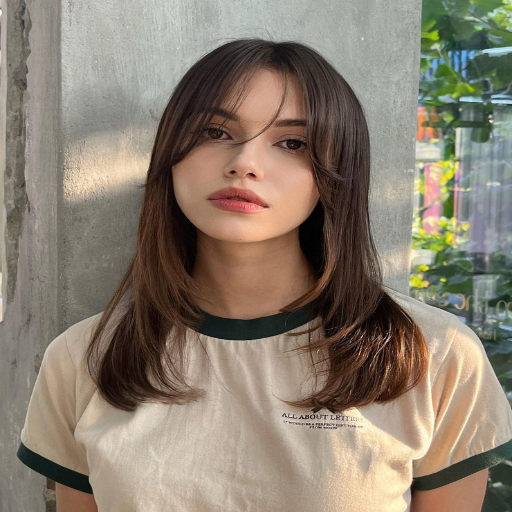

In [5]:
image

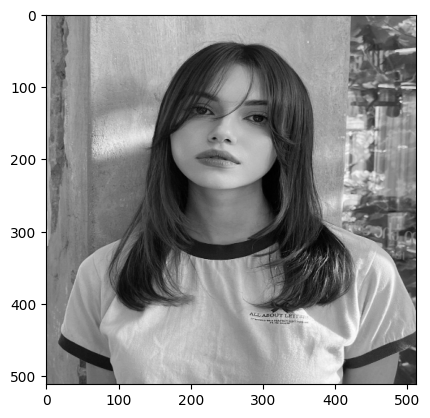

In [6]:
gray = cv2.cvtColor(
    image,
    cv2.COLOR_RGB2GRAY
)

plt.imshow(gray,cmap='gray')
plt.show()

In [8]:
gray_blur = cv2.medianBlur(
    gray,
    7
)

In [9]:
edges = cv2.adaptiveThreshold(
    gray_blur,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9,
    9
)

In [10]:
color = cv2.bilateralFilter(
    image,
    9,
    250,
    250
)

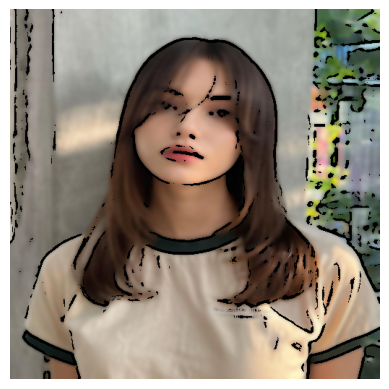

In [11]:
cartoon = cv2.bitwise_and(
    color,
    color,
    mask=edges
)

plt.imshow(cartoon)
plt.axis('off')
plt.show()

In [12]:
data = np.float32(
    image.reshape((-1,3))
)

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    20,
    0.001
)
K = 8

ret,label,center = cv2.kmeans(
    data,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

center = np.uint8(center)

result = center[label.flatten()]

quantized = result.reshape(
    image.shape
)

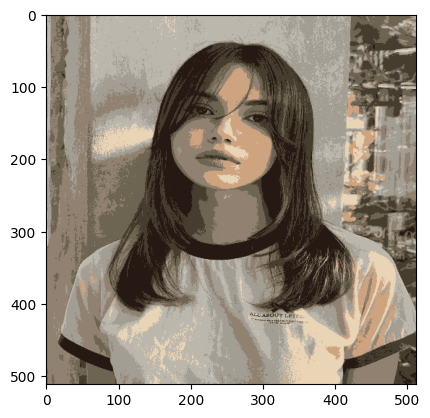

In [13]:
plt.imshow(quantized)
plt.show()